In [2]:
import pandas as pd

from paths import *
from analysis_utils import get_aggregated_dataframe

from sklearn.metrics import f1_score
import plotnine as p9
# create plot output folders
import os
plot_output_folder = f"data_exploration_plots"
os.makedirs(plot_output_folder, exist_ok=True)


df_results_aggregated, df_case, df_case_merged = get_aggregated_dataframe(experiment_folders_test)
df_case_merged.head()


,case_idxs,human_preds,human_confs,llm_preds,llm_reasoning,is_correct_multi,is_correct_maj,humans_agree,human_maj,idx_new,...,User Prompt,model_name,num_params,config_path,temperature,Text/Decision,Year,link,archive_link,CASE OUTCOME
0,-1.0,"('NO CREDIBILITY ASSESSMENT', 'NO CREDIBILITY ...","(('HIGH', '-'), ('HIGH', '-'), (None, None))",NO CREDIBILITY ASSESSMENT,NaN,True,True,True,NO CREDIBILITY ASSESSMENT,0,...,UP2,microsoft/phi-4,14.0,experiment_configs/ACLW_test200.yml,0,Nævnet omgjorde i april 2023 Udlændingestyrels...,2023,https://fln.dk/praksis/2023/maj/29b-graek20233/,https://web.archive.org/web/20260228212808/htt...,rejection_reversed
1,-1.0,"('NEGATIVE CREDIBILITY ASSESSMENT', 'NEGATIVE ...","(('HIGH', 'HIGH'), ('HIGH', 'HIGH'), (None, No...",NEGATIVE CREDIBILITY ASSESSMENT,NaN,True,True,True,NEGATIVE CREDIBILITY ASSESSMENT,1,...,UP2,microsoft/phi-4,14.0,experiment_configs/ACLW_test200.yml,0,Nævnet stadfæstede i maj 2025 Udlændingestyrel...,2025,https://fln.dk/praksis/2025/maj/arme20255/,https://web.archive.org/web/20260303200243/htt...,rejection_upheld
2,-1.0,"('NO CREDIBILITY ASSESSMENT', 'NO CREDIBILITY ...","(('HIGH', '-'), ('HIGH', '-'), (None, None))",NO CREDIBILITY ASSESSMENT,NaN,True,True,True,NO CREDIBILITY ASSESSMENT,2,...,UP2,microsoft/phi-4,14.0,experiment_configs/ACLW_test200.yml,0,Nævnet stadfæstede i juli 2025 Udlændingestyre...,2025,https://fln.dk/praksis/2025/juni/dub-tysk202518/,https://web.archive.org/web/20260303200553/htt...,rejection_upheld
3,-1.0,"('NO CREDIBILITY ASSESSMENT', 'NO CREDIBILITY ...","(('MEDIUM', '-'), ('HIGH', '-'), (None, None))",NO CREDIBILITY ASSESSMENT,NaN,True,True,True,NO CREDIBILITY ASSESSMENT,3,...,UP2,microsoft/phi-4,14.0,experiment_configs/ACLW_test200.yml,0,Nævnet stadfæstede i juli 2025 Udlændingestyre...,2025,https://fln.dk/praksis/2025/juli/dub-tysk202519/,https://web.archive.org/web/20260303200703/htt...,rejection_upheld
4,-1.0,"('NO CREDIBILITY ASSESSMENT', 'NO CREDIBILITY ...","(('HIGH', '-'), ('HIGH', '-'), (None, None))",NO CREDIBILITY ASSESSMENT,NaN,True,True,True,NO CREDIBILITY ASSESSMENT,4,...,UP2,microsoft/phi-4,14.0,experiment_configs/ACLW_test200.yml,0,Nævnet stadfæstede i maj og 2025 Udlændingesty...,2025,https://fln.dk/praksis/2025/maj/29b-tysk20253/,https://web.archive.org/web/20260303211724/htt...,rejection_upheld


In [3]:
CORRECTNESS_MEASURE = "is_correct_maj"

columns_of_interest = ["idx_new","human_preds","human_confs","humans_agree", "Text/Decision", "Year"]

df_case_accuracy = df_case_merged.groupby(columns_of_interest)[CORRECTNESS_MEASURE].mean().reset_index()
df_case_nunique = df_case_merged.groupby(columns_of_interest)["llm_preds"].nunique().reset_index()
df_case_majvote = df_case_merged.groupby(columns_of_interest)["llm_preds"].agg(pd.Series.mode).reset_index()
df_case_nmajvote = df_case_merged.groupby(columns_of_interest)["llm_preds"].apply(lambda x: x.value_counts().iloc[0]).reset_index()

# combine the 3 dataframes into one dataframe
df_case_agg = df_case_accuracy.merge(df_case_nunique, on=columns_of_interest)
df_case_agg = df_case_agg.merge(df_case_majvote, on=columns_of_interest)
df_case_agg = df_case_agg.merge(df_case_nmajvote, on=columns_of_interest)
df_case_agg.rename(columns={"llm_preds_x": "llm_preds_nunique", "llm_preds_y": "llm_preds_majvote", "llm_preds": "llm_preds_majvote_n"}, inplace=True)
print("\nAccuracy per case:")

assert len(df_case_agg) == 200, f"Expected 200 unique cases, but got {len(df_case_agg)}. Check the grouping and merging steps for correctness."

assert len(df_case_agg[df_case_agg["humans_agree"] == False]) == 4

df_case_agg.sort_values(by=["is_correct_maj"], ascending=True).head()


Accuracy per case:


,idx_new,human_preds,human_confs,humans_agree,Text/Decision,Year,is_correct_maj,llm_preds_nunique,llm_preds_majvote,llm_preds_majvote_n
176,176,"('NO CREDIBILITY ASSESSMENT', 'NO CREDIBILITY ...","(('LOW', '-'), ('MEDIUM', '-'), (None, None))",True,Nævnet meddelte i januar 2023 opholdstilladels...,2023,0.000000,1,POSITIVE CREDIBILITY ASSESSMENT,15
77,77,"('NO CREDIBILITY ASSESSMENT', 'NO CREDIBILITY ...","(('LOW', '-'), ('LOW', '-'), (None, None))",True,Nævnet stadfæstede i november 2018 Udlændinges...,2018,0.066667,2,NEGATIVE CREDIBILITY ASSESSMENT,14
129,129,"('POSITIVE CREDIBILITY ASSESSMENT', 'POSITIVE ...","(('HIGH', 'MEDIUM'), ('HIGH', 'LOW'), (None, N...",True,Nævnet meddelte i august 2016 opholdstilladels...,2016,0.133333,2,NEGATIVE CREDIBILITY ASSESSMENT,13
70,70,"('POSITIVE CREDIBILITY ASSESSMENT', 'POSITIVE ...","(('HIGH', 'HIGH'), ('HIGH', 'MEDIUM'), (None, ...",True,Nævnet meddelte i marts 2019 opholdstilladelse...,2019,0.133333,2,NEGATIVE CREDIBILITY ASSESSMENT,13
165,165,"('NEGATIVE CREDIBILITY ASSESSMENT', 'NEGATIVE ...","(('MEDIUM', 'LOW'), ('HIGH', 'HIGH'), (None, N...",True,Nævnet i Udlændingeservices afgørelse vedrøren...,2009,0.133333,3,POSITIVE CREDIBILITY ASSESSMENT,7


In [4]:
outcomes = df_case_merged.groupby("idx_new")["CASE OUTCOME"].agg([("CASE OUTCOME", lambda x: list(set(x))[0])])
test_set_outcome = pd.merge(df_case_agg, outcomes, on="idx_new")

humans_withoutnone = [ [h for h in eval(p) if h is not None] for p in test_set_outcome.human_preds ]
human_maj = [max(h, key=h.count) for h in humans_withoutnone]
test_set_outcome.human_preds = human_maj

test_set_outcome["outcome_preds"] = test_set_outcome["CASE OUTCOME"].replace({
    "rejection_upheld": "NEGATIVE CREDIBILITY ASSESSMENT",
    "rejection_reversed": "POSITIVE CREDIBILITY ASSESSMENT",
    "remanded": "NO CREDIBILITY ASSESSMENT"})
outcomef1 = f1_score(test_set_outcome.outcome_preds, test_set_outcome.human_preds, average="macro")
print(f"Test set F1-score based on outcome heuristic: {outcomef1}")

Test set F1-score based on outcome heuristic: 0.5363735422868622


In [5]:
val_set_gt = pd.read_csv(val_set_csv_metadata)
valset = val_set_gt[["CASE OUTCOME","Q2: Credibility assessment sentiment"]]
valset = valset.rename(columns={"Q2: Credibility assessment sentiment":"human_preds"})
valset = valset.replace({"POSITIVE": "POSITIVE CREDIBILITY ASSESSMENT", "NEGATIVE": "NEGATIVE CREDIBILITY ASSESSMENT", "-":"NO CREDIBILITY ASSESSMENT",
                "rejection_reversed": "Reversed", "rejection_upheld": "Upheld", "remanded": "Remanded"})
valset["outcome_preds"] = valset["CASE OUTCOME"].replace({"Upheld": "NEGATIVE CREDIBILITY ASSESSMENT", "Reversed": "POSITIVE CREDIBILITY ASSESSMENT", "Remanded": "NO CREDIBILITY ASSESSMENT"})

outcomef1 = f1_score(valset.outcome_preds, valset.human_preds, average="macro")
print(f"Validation set F1-score based on outcome heuristic: {outcomef1}")

Validation set F1-score based on outcome heuristic: 0.47651775486827025


/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 3 x 2.2 in image.
/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/outcome_cred_confmat_fulldataset.png
/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 3 x 2.2 in image.
/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/outcome_cred_confmat_fulldataset.pdf


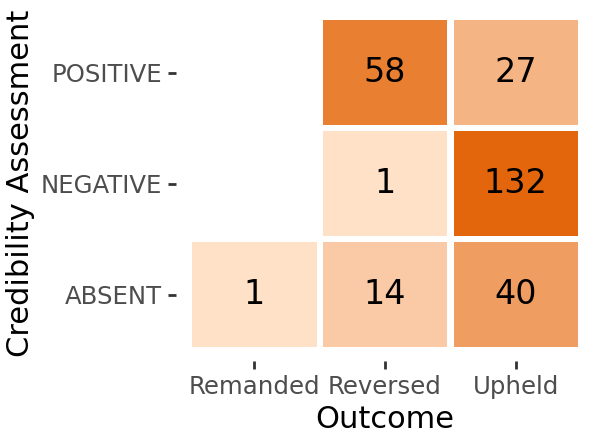

In [6]:

# merge with newmerge to have the same human_preds and outcome_preds format
combinedset = pd.concat([valset, test_set_outcome[["human_preds", "CASE OUTCOME","outcome_preds"]]], ignore_index=True)
assert len(combinedset) == 273, f"Expected combined set to have 273 rows, but got {len(combinedset)}. Check the merging steps for correctness."

combinedset.groupby(["CASE OUTCOME", "human_preds"]).size().reset_index().rename(columns={0:"count"})

combinedset.replace({"NO CREDIBILITY ASSESSMENT":"ABSENT","POSITIVE CREDIBILITY ASSESSMENT": "POSITIVE", "NEGATIVE CREDIBILITY ASSESSMENT": "NEGATIVE", "DISAGREEMENT":"DISAGREEMENT",
                     "rejection_reversed": "Reversed", "rejection_upheld": "Upheld", "remanded": "Remanded"}, inplace=True)

outcomef1 = f1_score(valset.outcome_preds, valset.human_preds, average="macro")
plot_valset = combinedset.groupby(["human_preds", "CASE OUTCOME"]).size().reset_index().rename(columns={0:"count"})
# Plot confidence matrix
plt = (
    p9.ggplot(plot_valset, p9.aes("CASE OUTCOME", "human_preds", fill="count"))
    + p9.geom_tile(p9.aes(width=0.95, height=0.95))
    + p9.geom_text(p9.aes(label="count"), size=12, color="black")
    + p9.scale_fill_gradient(low="#FFE3CB",high="#E4660C", limits=[0,72])
    + p9.theme(axis_text_x=p9.element_text(rotation=0, hjust=0.5), figure_size=(3,2.2), legend_position="none", legend_margin=0.0)
    + p9.theme(  # new
        panel_background=p9.element_rect(fill="white"),
    )
    + p9.labs(x="Outcome", y="Credibility Assessment")
)
plt.save(f"{plot_output_folder}/outcome_cred_confmat_fulldataset.png")
plt.save(f"{plot_output_folder}/outcome_cred_confmat_fulldataset.pdf")
plt.show()